In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
path = "data/"
batch_size = 32
height = 72
width = 128

In [3]:
train = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=1234,
    image_size=(height,width),
    batch_size=batch_size
)
val = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=1234,
    image_size=(height,width),
    batch_size=batch_size
)

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.


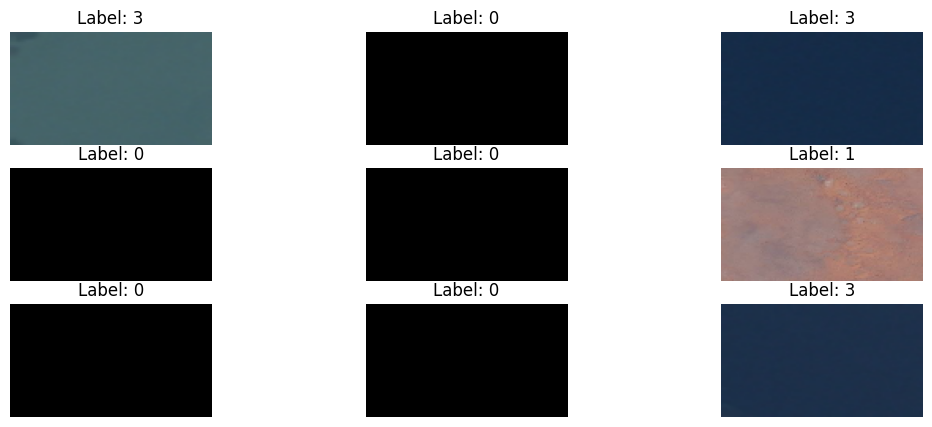

In [4]:
plt.figure(figsize=(13,5))
for i, (images, labels) in enumerate(train.take(1)):
    for j in range(9):
        ax = plt.subplot(3,3,j+1)
        plt.imshow(images[j].numpy().astype("uint8"))
        plt.title(f"Label: {labels[j].numpy()}")
        plt.axis("off")
plt.show()

In [5]:
amount = len(set(label for _, labels in train for label in labels.numpy()))
print(f"There are {amount} different classes")

There are 4 different classes


In [6]:
classes = {
    0: "cloudy",
    1: "desert",
    2: "water",
    3: "green_area"
}

In [7]:
model = Sequential([
    layers.Input(shape=(height, width, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(16,3,padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(amount)
])

In [8]:
model.compile(optimizer='adam',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [9]:
epochs = 20
history = model.fit(
    train,
    validation_data=val,
    epochs=epochs
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 36s 234ms/step - accuracy: 0.8357 - loss: 0.3554 - val_accuracy: 0.9005 - val_loss: 0.2225
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.8979 - loss: 0.2289 - val_accuracy: 0.8996 - val_loss: 0.2164
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 44s 196ms/step - accuracy: 0.9072 - loss: 0.2135 - val_accuracy: 0.8597 - val_loss: 0.3030
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - accuracy: 0.9219 - loss: 0.1761 - val_accuracy: 0.9183 - val_loss: 0.1703
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.9358 - loss: 0.1481 - val_accuracy: 0.9458 - val_loss: 0.1457
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 43s 199ms/step - accuracy: 0.9312 - loss: 0.1590 - val_accuracy: 0.9316 - val_loss: 0.1506
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 42s 206ms/step - accuracy: 0.9343 - loss: 0.1561 - val_accuracy: 0.8952 - val_loss: 0.1900
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.9410 - loss: 0

In [10]:
test_loss, test_acc = model.evaluate(val)
print(f"Test accuracy: {test_acc*100:.2f}%")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9911 - loss: 0.0381
Test accuracy: 99.11%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


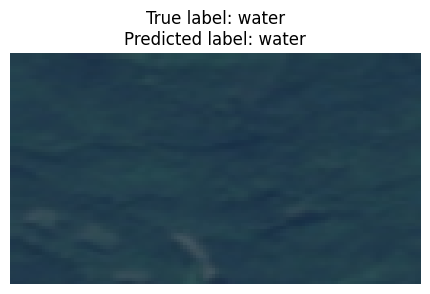

In [11]:
plt.figure(figsize=(6,3))
for images, labels in val.take(1):
    sample_image = images[1]
    true_label = labels[1]
    sample_image = tf.expand_dims(sample_image, axis=0)
    predictions = model.predict(sample_image)
    predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
    predicted_class = classes[predicted_class_index]
    plt.imshow(sample_image[0].numpy().astype("uint8"))
    plt.title(f"True label: {classes[true_label.numpy()]}\nPredicted label: {predicted_class}")
    plt.axis('off')
plt.show()